# 1. Solving the Schrödinger Equation I

Welcome to the first computational lab. By the end of it you will have written a
program that finds the allowed energies and wave functions of a quantum particle
trapped in a box — the *infinite square well* — using nothing more than linear
algebra.

This notebook has **two parts**:

1. **A quick Python primer.** A short, hands-on tour of exactly the Python tools
   you will use in these labs: plain Python, NumPy, Matplotlib, SciPy, and SymPy.
   If you have programmed before, this will be quick; run every cell and try the
   *Your turn* boxes.
2. **The matrix-element method.** The physics: we turn the Schrödinger equation
   into a matrix eigenvalue problem and solve it numerically.

Run each code cell with **Shift+Enter**.

# Part 1 — A quick Python primer

Everything below shows up again later in the lab. The goal is not to teach all of
Python, just the handful of pieces we lean on.

## 1.1 Python essentials

Variables, functions (`def`), `for` loops, lists, and **list comprehensions**.
The list comprehension is worth special attention — we use it to build sets of
basis functions like `[x**n * (x-a) for n in range(1, Nb+1)]`.

In [1]:
# Variables hold values
a = 1
greeting = "hello"

# A function takes inputs and returns an output
def square(t):
    return t**2

print(square(3))          # -> 9

# A for loop repeats work. range(1, 5) gives 1, 2, 3, 4
total = 0
for n in range(1, 5):
    total = total + n
print(total)              # -> 10

# A list is an ordered collection
my_list = [10, 20, 30]
print(my_list[0])         # -> 10  (indexing starts at 0)

# A list comprehension builds a list in one line
squares = [n**2 for n in range(1, 5)]
print(squares)            # -> [1, 4, 9, 16]

9
10
10
[1, 4, 9, 16]


**Your turn.** Using a list comprehension, build the list
`[n**2 * (n - 1) for n in 1..4]` and print it. (This is the same pattern as the
basis functions you will construct later.)

In [2]:
print([n**2 * (n - 1) for n in range(1, 5)])

[0, 4, 18, 48]


## 1.2 NumPy — arrays and linear algebra

NumPy gives us fast numerical arrays and a linear-algebra toolbox. We mainly use
it to make arrays (`np.zeros`, `np.empty`, `np.arange`), take absolute values
(`np.abs`), and — crucially — to find eigenvalues and eigenvectors of a symmetric
matrix with `np.linalg.eigh`.

In [3]:
import numpy as np

v = np.zeros(4)               # array of four 0.0's
print(v)

grid = np.arange(0, 1.01, 0.25)   # 0, 0.25, 0.5, 0.75, 1.0
print(grid)

print(np.abs(-2.5))           # -> 2.5

# Eigenvalues/eigenvectors of a real symmetric matrix
A = np.array([[2.0, 1.0],
              [1.0, 2.0]])
evals, evecs = np.linalg.eigh(A)
print("eigenvalues :", evals)
print("eigenvectors (columns):")
print(evecs)

[0. 0. 0. 0.]
[0.   0.25 0.5  0.75 1.  ]
2.5
eigenvalues : [1. 3.]
eigenvectors (columns):
[[-0.70710678  0.70710678]
 [ 0.70710678  0.70710678]]


`np.linalg.eigh` returns the eigenvalues in increasing order, and the
*columns* of the second output are the corresponding eigenvectors. We will read
energies out of the eigenvalues and wave-function coefficients out of the
eigenvectors.

## 1.3 Matplotlib — plotting

We visualize wave functions, coefficients, and energy levels. The basic recipe is
`fig, ax = plt.subplots()`, then `ax.plot(...)`, then labels and `plt.show()`.

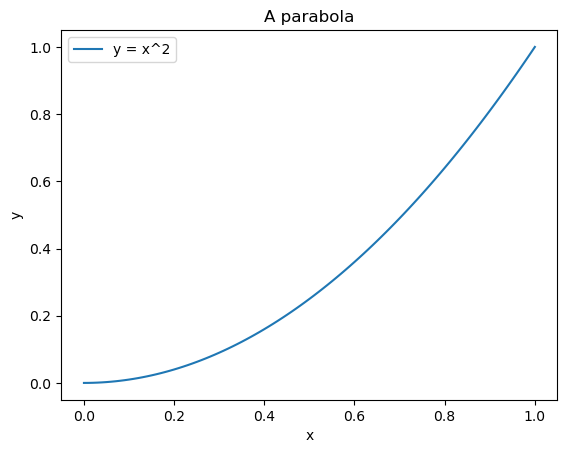

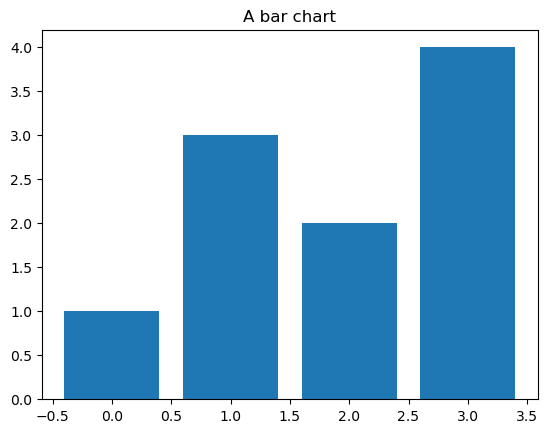

In [4]:
import matplotlib.pyplot as plt

x = np.arange(0, 1.01, 0.01)
y = x**2

fig, ax = plt.subplots()
ax.plot(x, y, label='y = x^2')
plt.title('A parabola')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

# A bar chart (used later for expansion coefficients)
plt.bar(np.arange(4), [1, 3, 2, 4])
plt.title('A bar chart')
plt.show()

## 1.4 SciPy — numerical integration

The *matrix elements* we need are integrals. `scipy.integrate.quad` computes a
definite integral numerically and returns `(value, estimated_error)`. Extra
parameters for the integrand are passed through `args`.

In [5]:
from scipy.integrate import quad

# Integral of x^2 from 0 to 1 is 1/3
value, error = quad(lambda x: x**2, 0, 1)
print(value)                  # -> 0.3333...

# Passing extra arguments to the integrand
def linear(x, slope):
    return slope * x

result = quad(linear, 0, 1, args=(2.0,))[0]   # integral of 2x from 0 to 1 = 1
print(result)                 # -> 1.0

0.33333333333333337
1.0


## 1.5 SymPy — symbolic mathematics

SymPy does algebra and calculus *exactly*, with symbols instead of numbers. We
use it to orthonormalize basis functions, take derivatives (`sym.diff`), do
integrals (`sym.integrate`), and then turn a symbolic expression into a fast
numerical function with `sym.lambdify`.

In [6]:
import sympy as sym

x = sym.Symbol("x")           # a symbolic variable
expr = x**2 * (x - 1)

print(sym.diff(expr, x))                 # derivative d/dx
print(sym.diff(expr, x, 2))              # second derivative
print(sym.integrate(expr, (x, 0, 1)))    # definite integral from 0 to 1
print(sym.sqrt(2))                       # exact sqrt(2)

# Turn the symbolic expression into a plain numerical function
f = sym.lambdify(x, expr)
print(f(2.0))                            # -> 4.0

x**2 + 2*x*(x - 1)
2*(3*x - 1)
-1/12
sqrt(2)
4.0


That is the whole toolkit. With these five pieces you can read every line of
code in the rest of the lab. On to the physics.

# Part 2 — Solving the Schrödinger equation

We now use the tools above to solve the time-independent Schrödinger equation for
a particle in an infinite square well.

## The matrix-element method<a id="ref1"></a><sup><a href="#fn1">1</a></sup>

The time-independent Schrödinger Equation (TISE) is an eigenvalue equation,

$$\hat{H}|\psi\rangle = E|\psi\rangle$$

where $\hat{H}$ is the Hamiltonian operator (a map that takes states $|\psi\rangle$ into other states $\hat{H} |\psi\rangle$) and $E$ is a number called the energy of the state. For a given $\hat{H}$, the solutions to the TISE form a special set $\{ \psi_1, \psi_2, \psi_3,  \ldots \}$ of states called the energy eigenstates or ''statationary states.'' For a finite-size system<a id="ref2"></a><sup><a href="#fn2">2</a></sup>, these states and their associated energies $\{ E_1, E_2, E_3, \ldots \}$ can be labeled by a discrete label $n = 1,2,3,\ldots$ with $\psi_1$ called the ''ground state.''

If a system can be in $N$ possible states, then $|\psi\rangle$ is represented as an $N$-dimensional vector and $\hat{H}$ is represented as a $N \times N$ matrix.  Modern computer programming languages contain useful functions for solving linear algebra problems like finding eigenvalues and eigenvectors and therefore for solving the TISE. The parameter $N$ plays a similar role to the timestep in previous labs, with exact results obtained as $N \rightarrow \infty$ but computers only good at working with finite $N$. Here we will use python's [NumPy package](https://numpy.org) to efficiently perform the matrix operations and python's [SymPy package](https://sympy.org) to perform symbolic algebra and take derivatives for us.










### Theoretical background

Our aim is to solve the the time-independent Schrödinger Equation,

$$ \hat{H}|\psi_n\rangle = E_n|\psi_n\rangle ,$$

for any arbitrary Hamiltonian $\hat{H}$. Let's begin by introducing a set of _orthonormal_ basis functions $\{|\phi_j\rangle\}$ that are __not__ the eigenfunctions of the given Hamiltonian, but that __satisfiy the same boundary conditions__ as the desired solutions.  Orthonormal means $\langle \phi_i |\phi_j \rangle = \delta_{ij}$, where $\delta_{ij}$ is 1 if $i=j$ and 0 if $i \neq j$.

In this case, we can expand the solutions to the TISE in terms of the basis functions as

$$ \quad\qquad |\psi_n\rangle = \sum_j c_n^j |\phi_j\rangle\,, \qquad(1)$$

where the sum runs from 1 to $N$. Using the basis functions, the TISE becomes

$$ \sum_j c_n^j \hat{H}|\phi_j\rangle = E_n \sum_j c_n^j|\phi_j\rangle .$$

Now let's take the inner product of the TISE with one of the basis functions, $\langle \phi_i|$:

$$ \sum_j c_n^j \langle \phi_i| \hat{H}|\phi_j\rangle = E_n \sum_j c_n^j \langle \phi_i|\phi_j\rangle .$$

Because we are using an orthonormal basis, the inner product $\langle\phi_i|\phi_j\rangle = \delta_{ij}$.  The quantity $\langle\phi_i| \hat{H}|\phi_j\rangle \equiv H_{ij} = H_{ji}^*$ is the <b>"ij" matrix element of the Hamiltonian operator between basis functions $i$ and $j$</b>.  Thus, the TISE becomes

$$ \sum_j H_{ij} c_n^j  = E_n \sum_j \delta_{ij} c_n^j .$$

Expressing this equation in matrix form,


\begin{equation*}
    \qquad\qquad  \begin{bmatrix}
        H_{11} & H_{12} & H_{13} & \ldots  \\
        H_{21} & H_{22} & H_{23} & \ldots \\
        H_{31} & H_{32} & H_{33} & \ldots \\
        \vdots & \vdots & \vdots & \ddots
    \end{bmatrix}
    \begin{bmatrix}
        c_n^1 \\
        c_n^2 \\
        c_n^3 \\
        \vdots
    \end{bmatrix}
     = E_n
    \begin{bmatrix}
        c_n^1 \\
        c_n^2 \\
        c_n^3 \\
        \vdots
    \end{bmatrix}
        \mathrm{,}  \qquad(2)
\end{equation*}


we can see that it is an eigenvalue equation.  We will refer to Eq. (2) as the <b>"matrix-element equation."</b>   

The __eigenvalues__ of the matrix-element equation are the __energies__ of the stationary-state solutions to the TISE, and (in the $N\rightarrow \infty$ limit) are <i>independent of the basis functions $\{|\phi_j\rangle\}$ used to calculate the matrix elements $H_{ij}$</i>. The __eigenvectors__ of the matrix-element equation are the __coefficients__ of the corresponding wave functions in terms of the basis functions, and will necessarily <i>depend upon the basis functions employed.</i>  Given a consistent set of basis functions $\{|\phi_j\rangle\}$ and coefficients $\{c_n^j\}$, however, the wave functions calculated via Eq. (1) are basis independent.
    
We're going to switch between braket and ''wavefunction'' notation a lot. The big idea is that position states $|x\rangle$ form a basis for the quantum states of a single particle. The fact that the probabilities of the particles being in any possible position sum to 1 is encoded by the statement
    
$$ 1 = \int_{-\infty}^\infty dx\  |x \rangle \langle x | .$$
    
        
We can use this to convet brakets into integrals of functions
    
$$ \langle \phi_i | \phi_j \rangle = \int_{-\infty}^\infty dx\ \langle \phi_i | x \rangle \langle x | \phi_j \rangle  \equiv \int_{-\infty}^\infty dx\  \phi_i(x)^* \phi_j(x), $$

    
where the wavefunction $\phi_j(x) \equiv \langle x | \phi_j \rangle$. Note that as an inner product $\langle x | \phi_j \rangle$ is a scalar rather than a vector, but it depends on the value of $x$ and is therefore written as a function $\phi_j(x)$.
    
Matrix elements of linear operators like the derivative (the derivative is an operator in the sense that it maps functions to functions and its linear because $\frac{d}{dx}(f+g) = \frac{df}{dx} + \frac{dg}{dx}$ can then be computed as integrals
    
$$ \langle \phi_i | \frac{d}{dx} | \phi_j \rangle = \int_{-\infty}^\infty dx\ \langle \phi_i | x \rangle \frac{d}{dx} \langle x | \phi_j \rangle  \equiv \int_{-\infty}^\infty dx\  \phi_i(x)^* \frac{d}{dx}\phi_j(x). $$

### Algorithm

<div class="alert alert-info">

We are now ready to write down the <b>matrix-element algorithm</b>.  To find the stationary-state solutions of a given Hamiltonian $\hat{H}$:

1. choose a set of basis functions $\{|\phi_j\rangle\}$ that satisfy the boundary conditions imposed by the potential,
2. calculate the matrix elements $H_{ij} = \langle\phi_i| \hat{H}|\phi_j\rangle$ in this basis via Eq. (3) below
3. calculate the eigenvalues and eigenvectors of the Hamiltonian matrix via Eq. (2)
4. constuct the stationary-state wave functions from the coefficients (_i.e._, eigenvectors) and basis functions via Eq. (1)

</div>

### Numerical errors

Although the dimension of the linear vector space spanned by all normalizable wave functions (_i.e._, Hilbert space) is infinite, in practice we must <b>truncate</b> the number of basis vectors in the sum in Eq. (1) -- and hence the dimensions of the Hamiltonian matrix in Eq. (2) -- so that our calculation can be performed on a computer.
    
For $N$ basis vectors, since $\hat{H}$ is Hermitian (that is $H_{ji} = H_{ij}^*$), the number of independent matrix elements $H_{ij}$ is $N(N+1)/2$.  Each of these matrix elements $H_{ij}$ is given by an integral over all space,

$$ H_{ij} =  \langle \phi_i | \hat{H} | \phi_j \rangle =  \int_{-\infty}^{\infty} dx\ \phi_i^*(x) H(x) \phi_j(x) \,  , \qquad(3)$$

that can be evaulated numerically. Here $\phi_j(x) = \langle x | \phi_j \rangle$ is the ''wavefunction'' describing  each basis vector in position space<a id="ref3"></a><sup><a href="#fn3">3</a></sup>. The calculation of these matrix elements is typically the most time-consuming portion of the matrix-element computation.

When using numerical methods, one must quantify any errors introduced from approximations, which are typically due to either discretizing a continuous variable or truncating an infinite series. With the matrix-element approach, we are introducing an error into our calculation by truncating the number of basis vectors.  For a given choice of basis, we can improve the accuracy of the resulting energies and wave functions by using a larger number of basis vector. Further, we can <b>quantify the truncation error</b> in our calculation by varying the number of basis vectors and observing by how much our results change.


---

**Footnotes**

<a id="fn1"></a>**1.** Written by Michael Wagman based on exercises adapted by Ruth Van de Water from Daniel Schroeder's ["Notes on Quantum Mechanics"](http://physics.weber.edu/schroeder/quantum/QuantumBook.pdf), section 2.2. Last updated 7/9/2021. [↩](#ref1)

<a id="fn2"></a>**2.** Infinite-size systems sometime have a discrete spectrum of states called ''bound states.'' For example, the Hydrogen atom, other atoms, and most atomic nuclei include a discrete spectrum with multiple bound states even in an infinitely large space. Without sufficiently attractive interactions between particles, infinite-volume systems only have a continuus spectrum of ''scattering states'' similar to the free particle case where the energy $E = p^2 / (2M)$ can be any positive real number. [↩](#ref2)

<a id="fn3"></a>**3.** You can use the right-hand-side of Eq. (3) as it's written to calculate matrix elements -- wavefunctions $\phi_j(x)$ are more convenient for computors than abstract states $| \phi_j \rangle$. If you want to derive where it comes from, to get to the right-hand-side we used $1 = \int_{-\infty}^\infty dx\, |x\rangle \langle x |$ and assumed that the Hamiltonian can be expressed as $\langle x | \hat{H} | y \rangle = H(x) \delta(x-y)$ where $\delta(x-y)$ is called a ["Dirac delta function"](https://phas.ubc.ca/~berciu/TEACHING/PHYS312/LECTURES/FILES/dirac.pdf). This gives us

$$H_{ij} = \int_{-\infty}^\infty dx \int_{-\infty}^\infty dy \ \langle \phi_i | x \rangle \langle x | \hat{H} | y \rangle \langle y | \phi_j \rangle = \int_{-\infty}^\infty dx \int_{-\infty}^\infty dy\  \phi_i^*(x) H(x)\delta(x-y) \phi_j(y) = \int_{-\infty}^{\infty} dx\ \phi_i^*(x) H(x) \phi_j(x). $$

[↩](#ref3)

# Numerical implementation

In the rest of the notebook, we will guide you through implementing the matrix-element method for the one-dimensional __infinite square well__ in Python,

$$
V(x)=\left\{\begin{array}{ll}
\infty & \quad x \leq 0, \\
0 & \quad  0 < x < a,\\
\infty & \quad x \geq a.
\end{array}
\right.
$$

Although this potential can be solved exactly, it is useful when writing code to first test it on a simple scenario for which the answer is known, and to then test it with scenarios of increasing complexity.  

<div class="alert alert-warning">

We will use <b>natural units</b> in our calculation, setting all of the quantities with dimensions ($a$, $m$, and $\hbar$) equal to 1.  With this choice, our units of energy are now $\frac{\displaystyle \hbar^2}{\displaystyle ma^2}$.  In other words, to convert the energies obtained in our simulation to SI units, we must multiply them by the quantity $\frac{\displaystyle \hbar^2}{\displaystyle ma^2}$.   The use of natural units will not only simplify our code, but it will also make our resuts more general.  This is because we can choose <i>any</i> values of of the particle mass $m$ and width of the well $a$ at a later date and re-interpret the results of our simulation using the appropriate conversion factor(s).   

</div>

## Preliminaries and function definitions

First import the modules [numpy](https://numpy.org) (_for matrix operations_); [scipy.integrate.quad](https://docs.scipy.org/doc/scipy/reference/generated/scipy.integrate.quad.html) (_to calculate the matrix elements and later normalize the wave functions_); and [matplotlib.pyplot](https://matplotlib.org) (_needed for plotting the wave functions_).

Also import the constants __math.pi__ and __math.inf__ for convience.

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
import sympy as sym
from math import pi as Pi

First define the __potential function V(x)__.   (_This isn't really necessary for the infinite square well -- which is constant throughout the integration region -- but will be needed for other potentials._)

In [8]:
a = 1                 # width of the well (natural units: hbar = m = a = 1)

def potential(x):
    # Zero inside the well. The infinite walls are enforced by the basis,
    # which is built to vanish at x = 0 and x = a, so we never evaluate V there.
    return 0.0

Next, choose a set of orthonormal __basis functions__ for $\psi(x)$ that satisfy the boundary conditions $\psi(x=0) = \psi(x=a) = 0$. We'll call the basis functions $\phi_j(x)$ where $j =1,2,3,\ldots$.

A convenient set of functions that we can build our basis using is $\{ x^j \}$ where $j \geq 0$ is an integer. Linear combinations of these basis functions are polynomials $\sum_j c^j x^j$ where the $c^j$ are numerical coefficients. These are a complete basis for smooth functions on the interval $0 \leq x \leq a$, but they don't satisfy the boundary conditions  $\psi(x=0) = \psi(x=a) = 0$ and they're not orthonormal (in particular, the integral of $x^i x^j$ doesn't vanish for $i \neq j$).

To enforce the boundary condition $\psi(x=0) = 0$, we can restrict our basis to include $\{ x^j \}$ with $j \geq 1$. To also enforce the boundary condition $\psi(x=a) = 0$, we can similarly restrict our basis to $\{ x^j (x-a) \}$ with $j \geq 1$. This now gives us a set of functions that satisfies the boundary conditions, but it's still not orthonormal.

There's a convenient procedure for taking a set of functions and returning an orthonormal set called the ["Gram-Schmidt process"](https://en.wikipedia.org/wiki/Gram%E2%80%93Schmidt_process). The following block of code runs this process on a set of functions called start_basis of the form $x^j (x-a)$ and produces a set of functions that are orthogonal and normalized. It uses a module called SymPy to accomplish this, but you don't need to worry about understanding all the details of the Gram-Schmidt process -- we'll verify below that the functions are orthonormal and satisfy $\psi(x=0) = \psi(x=a) = 0$, which means that the process did its job.

The symoblic manipulations below are time-consuming and may take one or two minutes to run for reasonable-sized bases. This is still less time than it would take a human to do all the algebra.

In [9]:
Nb = 4                              # number of basis functions

x = sym.Symbol("x")

# Start from x**(k+1) * (x - a) for k = 0, 1, ..., Nb-1.
# Each already vanishes at x = 0 and x = a (the boundary conditions),
# but they are not yet orthonormal.
start_basis = [x**(k + 1) * (x - a) for k in range(Nb)]

def inner_product(f, g):
    return sym.integrate(f * g, (x, 0, a))

# Gram-Schmidt: subtract the overlap with each finished function, then normalize.
orthonormal_basis = []
for f in start_basis:
    for g in orthonormal_basis:        # every g here is already orthonormal
        f = f - inner_product(g, f) * g
    f = f / sym.sqrt(inner_product(f, f))
    orthonormal_basis.append(sym.simplify(f))

for k, f in enumerate(orthonormal_basis):
    print(f"phi_{k}(x) =", f)

# Numerical version of each basis function (0-indexed, just like the list).
funcs = [sym.lambdify(x, f) for f in orthonormal_basis]

def basis(j, xx):                      # the j-th basis function at the point xx
    return funcs[j](xx)

phi_0(x) = sqrt(30)*x*(x - 1)
phi_1(x) = sqrt(210)*x*(x - 1)*(2*x - 1)
phi_2(x) = 3*sqrt(10)*x*(14*x**3 - 28*x**2 + 17*x - 3)
phi_3(x) = sqrt(2310)*x*(12*x**4 - 30*x**3 + 26*x**2 - 9*x + 1)


To see what these basis functions look like, we can make a plot

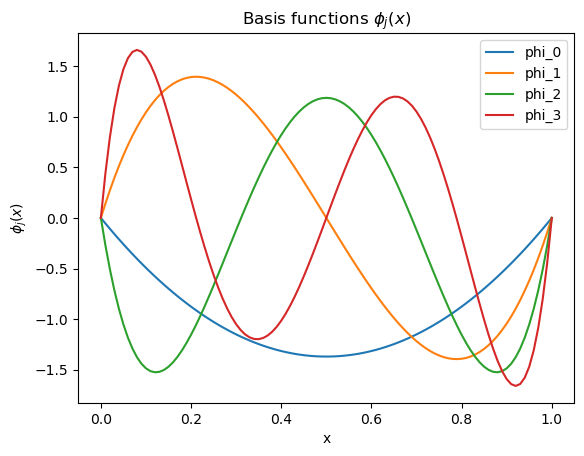

In [10]:
x_grid = np.linspace(0, a, 101)

fig, ax = plt.subplots()
for j in range(Nb):
    ax.plot(x_grid, [basis(j, xx) for xx in x_grid], label=f"phi_{j}")
plt.title("Basis functions $\\phi_j(x)$")
plt.xlabel("x")
plt.ylabel("$\\phi_j(x)$")
plt.legend()
plt.show()

## Matrix elements

Now we need to calculate the <b>matrix elements $H_{ij}$</b>.  

Inside the well, the particle is a free particle and the Hamiltonian only involves the kinetic energy piece

$$H_{ij} = K_{ij} = -\frac{\displaystyle \hbar^2}{\displaystyle 2m}\langle \phi_i| \frac{\displaystyle d^2 }{\displaystyle d x^2} |\phi_j\rangle = -\frac{\displaystyle \hbar^2}{\displaystyle 2m} \int_{-\infty}^{\infty} dx \ \phi_i(x)^*  \frac{\displaystyle d^2 }{\displaystyle d x^2}  \phi_j(x).$$

To evaluate this in position space we need the second derivatives of our wavefunctions

$$ \frac{\displaystyle d^2 }{\displaystyle d x^2} \phi_j(x), $$

which can be conveniently computed using SymPy -- taking derivatives is an automatic procedure that computers are good at doing without making mistakes!

In [11]:
# Second derivative of each basis function (0-indexed), as numerical functions.
d2funcs = [sym.lambdify(x, sym.diff(f, x, 2)) for f in orthonormal_basis]

def d2_basis(j, xx):
    return d2funcs[j](xx)

In [12]:
# Kinetic-energy matrix:  K_ij = <phi_i| -1/2 d^2/dx^2 |phi_j>
Kij = np.zeros((Nb, Nb))
for i in range(Nb):
    for j in range(Nb):
        Kij[i, j] = quad(lambda xx: -0.5 * basis(i, xx) * d2_basis(j, xx), 0, a)[0]

print(np.round(Kij, 4))

[[ 5.     -0.      1.7321  0.    ]
 [ 0.     21.      0.      9.9499]
 [ 1.7321 -0.     51.     -0.    ]
 [ 0.      9.9499 -0.     99.    ]]


### $\langle \phi_i| V(x) |\phi_j\rangle$  

Here, no calculation is needed because $V(x)=0$ throughout the integration region.  Therefore, all of the matrix elements are zero.

In [13]:
# Potential-energy matrix:  V_ij = <phi_i| V(x) |phi_j>
# Here V(x) = 0 inside the well, so every entry comes out 0.
Vij = np.zeros((Nb, Nb))
for i in range(Nb):
    for j in range(Nb):
        Vij[i, j] = quad(lambda xx: basis(i, xx) * basis(j, xx) * potential(xx), 0, a)[0]

print(np.round(Vij, 4))

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Eigenvalue equation

Now we find the eigenvalues and eigenvectors of the Hamiltonian. **The allowed
energies and wave functions are physical properties of the system, so they must
not depend on which basis functions we chose** — although with too few basis
functions (small `Nb`) the higher states will come out inaccurate.

`np.linalg.eigh` does the work. It returns

* `energies` — the energy of each state, in increasing order, so `energies[n]` is
  the energy of state `n`;
* `vectors` — the eigenvectors as the **columns** of a matrix. We transpose them
  into `coeffs`, so that `coeffs[n]` is the list of expansion coefficients
  $c_n^j$ for state `n`.

For comparison, the exact infinite-square-well energies in natural units are

$$ E_n = \frac{n^2 \pi^2}{2}. $$

In [14]:
# The Hamiltonian matrix is H = K + V.
H = Kij + Vij

# eigh returns eigenvalues in increasing order and eigenvectors as COLUMNS.
energies, vectors = np.linalg.eigh(H)

# Transpose once so that coeffs[n] is the coefficient list for state n.
coeffs = vectors.T

print("state   numerical       exact")
for n in range(Nb):
    exact = (n + 1)**2 * Pi**2 / 2
    print(f"{n+1:<7} {energies[n]:<14.6f} {exact:.6f}")

state   numerical       exact
1       4.934875       4.934802
2       19.750776      19.739209
3       51.065125      44.413220
4       100.249224     78.956835


## Energies and wave functions

The plot below shows the coefficients $c_{n}^{j}$ versus the basis index $j$ for the energy eigenstates.  The contributions from the individual basis functions $\phi_j(x)$ <b>must decrease with increasing $j$</b> if we are going to be able to truncate the expansion of the exact wave function $\psi_{n}(x)$ in Eq. (1).  _(If this is not the case, we must use another approach!)_  Fortunately, we can see that in the case of the (in)finite square well, only a small number of basis vectors are needed to capture the behavior of the exact wave function.  

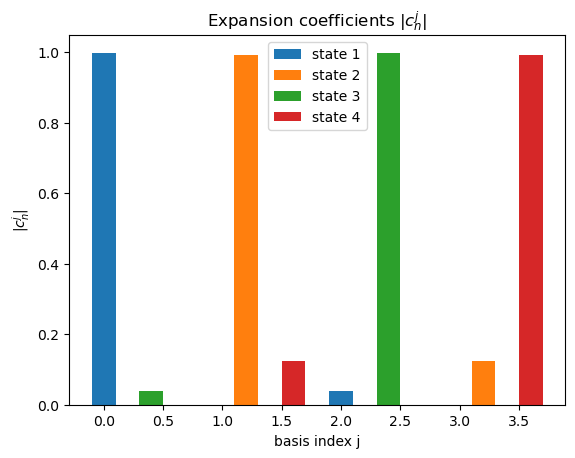

In [15]:
# coeffs[n][j] is how much basis function j contributes to state n.
# Plotting |coeffs[n][j]| shows how few basis functions really matter.
fig, ax = plt.subplots()
width = 0.8 / Nb
for n in range(Nb):
    ax.bar(np.arange(Nb) + n * width, np.abs(coeffs[n]), width, label=f"state {n+1}")
plt.title("Expansion coefficients $|c_n^j|$")
plt.xlabel("basis index j")
plt.ylabel("$|c_n^j|$")
plt.legend()
plt.show()

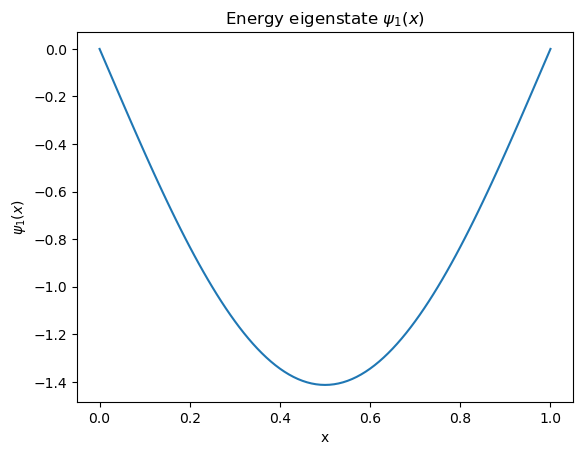

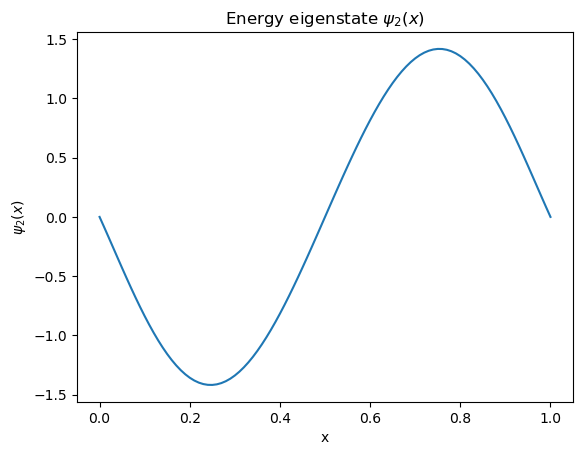

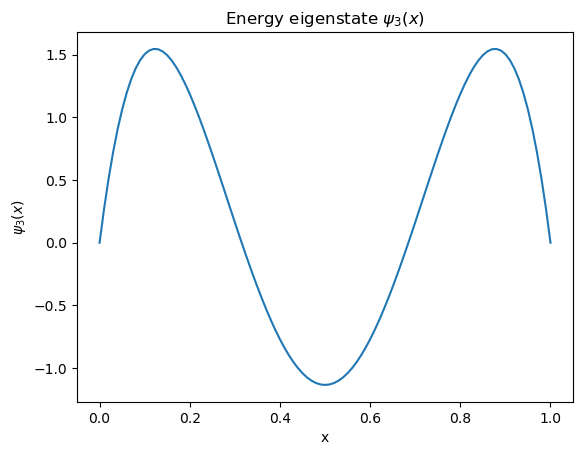

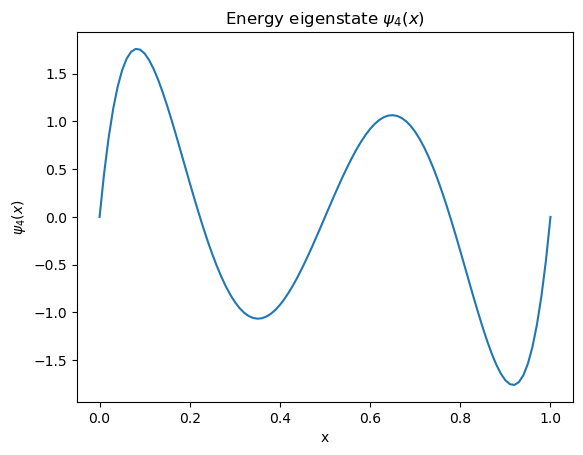

In [16]:
x_grid = np.linspace(0, a, 101)

for n in range(Nb):
    # psi_n(x) = sum over j of coeffs[n][j] * phi_j(x)
    psi_grid = [sum(coeffs[n][j] * basis(j, xx) for j in range(Nb)) for xx in x_grid]
    fig, ax = plt.subplots()
    ax.plot(x_grid, psi_grid)
    plt.title(f"Energy eigenstate $\\psi_{{{n+1}}}(x)$")
    plt.xlabel("x")
    plt.ylabel(f"$\\psi_{{{n+1}}}(x)$")
    plt.show()

Now let's make an __energy-level diagram__.  This is a plot of the energies for all states as obtained from the eigenvalues of the Hamiltonian in our basis.

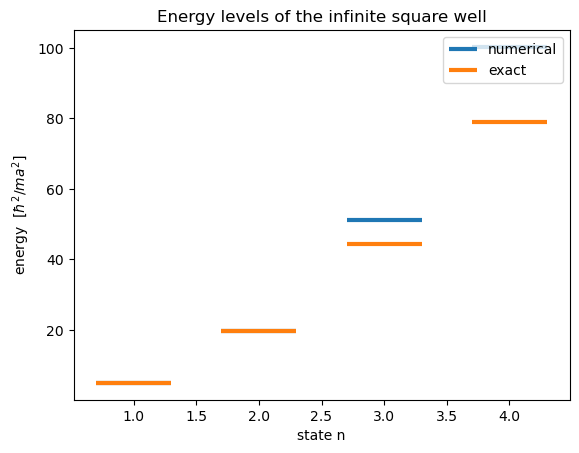

In [17]:
levels = np.arange(1, Nb + 1)
exact_levels = levels**2 * Pi**2 / 2

fig, ax = plt.subplots()
ax.hlines(energies,      levels - 0.3, levels + 0.3, color="C0", lw=3, label="numerical")
ax.hlines(exact_levels,  levels - 0.3, levels + 0.3, color="C1", lw=3, label="exact")
plt.title("Energy levels of the infinite square well")
plt.xlabel("state n")
plt.ylabel("energy  $[\\hbar^2 / m a^2]$")
ax.legend()
plt.show()

# Exercises

## Infinite square well part 1

1. Check that the basis functions satisfy the boundary conditions: $\phi_j(x=0) = \phi_j(x=a) = 0$. Next, check that the basis functions are orthonormal. To do this, you can use SciPy's quad function to do the integrals
$$N_{ij} = \int_0^a \phi_i(x) \phi_j(x)\ dx  $$
and check that $N_{ij} = \delta_{ij}$. The code for making $N_{ij}$ should be similar to the code for making $V_{ij}$, but without including the potential function.
Any set of functions satisfying the boundary conditions and orthonormality are a valid basis that we can use for this lab, so this verifies that the polynomials that we have constructed are a valid basis.


2. How many basis functions Nb are required to reproduce the exact ground-state energy within 0.1 (in natural units with hbar=m=1)? How about the minimum Nb to reproduce the exact ground-state energy within $10^{-6}$? How far off is the first-excited-state energy for this choice of Nb?



In [18]:
# Exercise 1 — boundary conditions and orthonormality
# Boundary conditions: phi_j(0) and phi_j(a) should both be zero.
for j in range(Nb):
    print(f"phi_{j}(0) = {basis(j, 0):.1e},   phi_{j}(a) = {basis(j, a):.1e}")

# Orthonormality: N_ij = integral_0^a phi_i(x) phi_j(x) dx should be the identity.
Nij = np.zeros((Nb, Nb))
for i in range(Nb):
    for j in range(Nb):
        Nij[i, j] = quad(lambda xx: basis(i, xx) * basis(j, xx), 0, a)[0]
print("\nN_ij =")
print(np.round(Nij, 6))


# Exercise 2 — how many basis functions does the ground state need?
def isw_energies(nb):
    """Re-run the matrix-element method with nb basis functions; return the energies."""
    onb = []
    for k in range(nb):
        f = x**(k + 1) * (x - a)
        for g in onb:
            f = f - inner_product(g, f) * g
        f = f / sym.sqrt(inner_product(f, f))
        onb.append(sym.simplify(f))
    fns = [sym.lambdify(x, f) for f in onb]
    d2  = [sym.lambdify(x, sym.diff(f, x, 2)) for f in onb]
    K = np.zeros((nb, nb))
    for i in range(nb):
        for j in range(nb):
            K[i, j] = quad(lambda xx: -0.5 * fns[i](xx) * d2[j](xx), 0, a)[0]
    return np.linalg.eigvalsh(K)

exact_E0 = Pi**2 / 2          # exact ground state
exact_E1 = 4 * Pi**2 / 2      # exact first excited state
print(" Nb   E0            err(E0)   err(E1)")
for nb in range(2, 9):
    E = isw_energies(nb)
    print(f" {nb:<3}  {E[0]:.8f}    {abs(E[0]-exact_E0):.1e}   {abs(E[1]-exact_E1):.1e}")

# Findings:
#   * the ground state is within 0.1 of exact already at Nb = 2,
#   * within 1e-6 at Nb = 5,
#   * at Nb = 5 the first excited state is still off by ~0.012 — higher states
#     need more basis functions to reach the same accuracy.

phi_0(0) = -0.0e+00,   phi_0(a) = 0.0e+00
phi_1(0) = 0.0e+00,   phi_1(a) = 0.0e+00
phi_2(0) = -0.0e+00,   phi_2(a) = 0.0e+00
phi_3(0) = 0.0e+00,   phi_3(a) = 0.0e+00

N_ij =
[[ 1.  0.  0.  0.]
 [ 0.  1. -0. -0.]
 [ 0. -0.  1. -0.]
 [ 0. -0. -0.  1.]]
 Nb   E0            err(E0)   err(E1)
 2    5.00000000    6.5e-02   1.3e+00
 3    4.93487481    7.3e-05   1.3e+00


 4    4.93487481    7.3e-05   1.2e-02


 5    4.93480222    1.7e-08   1.2e-02


 6    4.93480222    1.7e-08   2.8e-05


 7    4.93480220    1.3e-12   2.8e-05


 8    4.93480220    1.3e-12   2.4e-08
